[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_16/SFM_ch16_seminar/SFM_ch16_seminar.ipynb)

# Statistics of Financial Markets — Seminar 16: Review

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 16: the slides "What You Need for Today" are a formula sheet for all chapters.
- Part A: six exam-type problems on paper, checked in code. Part B: three data tasks with an interpretation question. Part C: an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch16_seminar`: student version of the Seminar 16 notebook. Solved exercises (A1, A3, B1) are shown with code and output; the proposed exercises (A2, A4, A5, A6, B2, B3, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- The functions of the course: returns, performance, moments, Hill, autocorrelation, Ljung–Box, variance ratio, EWMA, GARCH(1,1)-t, VaR and ES, Kupiec, rolling VaR forecasts, Hurst (R/S).
- Helpers for the [Solved] tasks: A1, A3 and B1.

In [ ]:
from arch import arch_model
NAME = {'sp500': 'S&P 500', 'bet': 'BET', 'btc': 'Bitcoin'}
ASSETS = ['sp500', 'bet', 'btc']
COLORS = {'sp500': '#1A3A6E', 'bet': '#CD0000', 'btc': '#B5853F'}
START = '2015-01-01'
LB_LAGS = 10
VR_Q = 5
HILL_FRAC = 0.025
LAMBDA = 0.94
ALPHA_VAR = 0.01
ALPHA_ES = 0.025
WINDOW = 500
OOS_START = '2017-01-01'
NMIN = 10
Z01, Z025 = stats.norm.ppf(0.01), stats.norm.ppf(0.025)


def returns(k, start=START, end=END):
    """Daily log returns in % on the series' own calendar (Bitcoin: 7 days a week)."""
    return log_returns(k, start, end)


def performance(k, start=START, end=END, rf=0.0):
    """Annualised mean log return and volatility with the actual frequency q, CAGR, Sharpe ratio (arithmetic mean,
    risk-free rate rf in % a year), maximum drawdown MDD = min_t (P_t / max_{s<=t} P_s - 1)."""
    p = load_close(k, start, end)
    r = 100 * np.log(p).diff().dropna()
    R = 100 * p.pct_change().dropna()
    q = periods_per_year(r)
    years = (p.index[-1] - p.index[0]).days / 365.25
    dd = p / p.cummax() - 1
    mean_ar = q * R.mean()
    vol = np.sqrt(q) * r.std()
    return {'n': int(len(r)), 'q': float(q), 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
            'mean_log': float(q * r.mean()), 'mean_arith': float(mean_ar), 'vol': float(vol),
            'cagr': float(100 * ((p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1)),
            'sharpe': float((mean_ar - rf) / vol), 'sharpe_se': float(np.sqrt((1 + ((mean_ar - rf) / vol) ** 2 / 2) / years)),
            'mdd': float(100 * dd.min()), 'mdd_date': dd.idxmin().date().isoformat(),
            'peak_date': p.loc[:dd.idxmin()].idxmax().date().isoformat(), 'growth': float(p.iloc[-1] / p.iloc[0])}


def moments(r):
    """Skewness S = m3 / m2^(3/2), excess kurtosis K = m4 / m2^2 - 3, Jarque-Bera JB = n/6 (S^2 + K^2/4) ~ chi2(2)."""
    x = np.asarray(r, float)
    e = x - x.mean()
    m2, m3, m4 = (np.mean(e ** j) for j in (2, 3, 4))
    S, K = m3 / m2 ** 1.5, m4 / m2 ** 2 - 3
    jb = len(x) / 6 * (S ** 2 + K ** 2 / 4)
    return {'skew': float(S), 'exkurt': float(K), 'jb': float(jb), 'p_jb': float(stats.chi2.sf(jb, 2))}


def hill(x, k):
    """Hill (1975): alpha_hat = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^(-1), X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x, float))[::-1]
    return float(1.0 / np.mean(np.log(x[:k] / x[k])))


def tail_index(r, frac=HILL_FRAC):
    """Hill tail index of the losses L = -r with k = frac * n, and its i.i.d. standard error alpha / sqrt(k)."""
    L = -np.asarray(r, float)
    k = int(round(frac * len(L)))
    a = hill(L[L > 0], k)
    return {'k': k, 'alpha': a, 'se': a / np.sqrt(k)}


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, m=LB_LAGS):
    """Ljung-Box Q(m) = T(T+2) sum_{k=1..m} rho_k^2 / (T-k) ~ chi2(m) under no autocorrelation."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return {'q': float(q), 'p': float(stats.chi2.sf(q, m)), 'crit': float(stats.chi2.ppf(0.95, m)), 'rho1': float(rho[0])}


def variance_ratio(x, q=VR_Q):
    """Lo and MacKinlay (1988): overlapping VR(q) with bias corrections, the i.i.d. statistic Z(q) and the
    heteroskedasticity-robust Z*(q) = (VR - 1) / sqrt(theta / T), theta = sum_{j<q} [2(q-j)/q]^2 delta_hat(j)."""
    x = np.asarray(x, float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = np.sum(e ** 2) / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu
    var_c = np.sum(agg ** 2) / (q * (T - q + 1) * (1 - q / T))
    vr = var_c / var_a
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = np.sum(e ** 2) ** 2
    theta = sum((2 * (q - j) / q) ** 2 * T * np.sum(e[j:] ** 2 * e[:-j] ** 2) / den for j in range(1, q))
    zs = (vr - 1) / np.sqrt(theta / T)
    return {'q': q, 'vr': float(vr), 'z': float(z), 'zs': float(zs), 'p_zs': float(2 * stats.norm.sf(abs(zs)))}


def ewma_var(r, lam=LAMBDA):
    """EWMA (RiskMetrics) variance sigma_t^2 = lam sigma_{t-1}^2 + (1 - lam) r_{t-1}^2, started at the variance of the
    first 30 returns; the value at t uses returns up to t-1 only."""
    x = np.asarray(r, float)
    s2 = np.empty(len(x))
    s2[0] = np.var(x[:30])
    for t in range(1, len(x)):
        s2[t] = lam * s2[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s2, index=r.index)


def garch_t(r):
    """GARCH(1,1) with constant mean and standardised Student-t innovations (maximum likelihood, arch package):
    persistence alpha + beta and half-life ln 0.5 / ln(alpha + beta) in days (None when alpha + beta is 1 to four
    decimals: an integrated GARCH, IGARCH)."""
    res = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off', options={'maxiter': 2000})
    p = res.params
    pers = float(p['alpha[1]'] + p['beta[1]'])
    return {'mu': float(p['mu']), 'omega': float(p['omega']), 'alpha': float(p['alpha[1]']), 'beta': float(p['beta[1]']),
            'nu': float(p['nu']), 'pers': pers, 'half_life': float(np.log(0.5) / np.log(pers)) if pers < 0.9999 else None}


def hs_var(x, a=ALPHA_VAR):
    """Historical simulation: VaR_a = -r_(k), k = ceil(n a), the k-th smallest return."""
    x = np.sort(np.asarray(x, float))
    return float(-x[int(np.ceil(len(x) * a - 1e-9)) - 1])


def hs_es(x, a=ALPHA_ES):
    """Historical simulation: ES_a = minus the mean of the k = ceil(n a) smallest returns."""
    x = np.sort(np.asarray(x, float))
    return float(-x[:int(np.ceil(len(x) * a - 1e-9))].mean())


def normal_var(x, a=ALPHA_VAR):
    """Normal VaR_a = -(mu + sigma z_a)."""
    return float(-(np.mean(x) + np.std(x, ddof=1) * stats.norm.ppf(a)))


def normal_es(x, a=ALPHA_ES):
    """Normal ES_a = -mu + sigma phi(z_a) / a."""
    return float(-np.mean(x) + np.std(x, ddof=1) * stats.norm.pdf(stats.norm.ppf(a)) / a)


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec (1995): LR_uc = -2 ln[(1-a)^(n-x) a^x / ((1-x/n)^(n-x) (x/n)^x)] ~ chi2(1)."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = ((n - x) * np.log(1 - ph) if ph < 1 else 0.0) + (x * np.log(ph) if x > 0 else 0.0)
    lr = float(-2 * (l0 - l1))
    return {'x': int(x), 'n': int(n), 'rate': float(100 * ph), 'lr': lr, 'p': float(stats.chi2.sf(lr, 1))}


def var_backtest(k, start=OOS_START, window=WINDOW, a=ALPHA_VAR):
    """One-day VaR 1% forecasts from `start`: historical simulation on the last `window` returns and EWMA-Normal
    (-sigma_t z_a, lambda = 0.94); exceptions r_t < -VaR_t, Kupiec test, most exceptions in 250 days."""
    r = log_returns(k, None, END)
    s2 = ewma_var(r)
    hs = (-r.rolling(window).quantile(a, interpolation='lower')).shift(1)
    ew = -np.sqrt(s2) * stats.norm.ppf(a)
    df = pd.DataFrame({'r': r, 'HS': hs, 'EWMA': ew}).loc[start:].dropna()
    out = {'n': int(len(df)), 'first': df.index[0].date().isoformat()}
    for m in ('HS', 'EWMA'):
        hit = (df['r'] < -df[m]).astype(int)
        out[m] = kupiec(int(hit.sum()), len(df), a)
        out[m]['max250'] = int(hit.rolling(250).sum().max())
        out[m]['mean_var'] = float(df[m].mean())
    return out, df


def block_sizes(N, nmin=NMIN, num=20):
    """About `num` block sizes spaced evenly on a log scale between nmin and N/4."""
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(N // 4), num)).astype(int))


def hurst_rs(x):
    """Hurst exponent: slope of log10 of the average R/S of the non-overlapping blocks of size n on log10 n."""
    x = np.asarray(x, float)
    sizes, out = block_sizes(len(x)), []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R, S = Y.max(axis=1) - Y.min(axis=1), X.std(axis=1)
        out.append(np.mean(R[S > 0] / S[S > 0]))
    return float(np.polyfit(np.log10(sizes), np.log10(out), 1)[0])


def a1_returns(prices=(50.0, 51.5, 49.8, 52.3, 47.9, 50.6), mu=0.04, sd=1.3, rf=3.0, q=252, years=10):
    """A1: simple and log returns, total return two ways, maximum drawdown and the recovery gain, annualisation and
    the Sharpe ratio with its standard error sqrt((1 + SR^2/2) / years)."""
    p = np.asarray(prices, float)
    R = 100 * (p[1:] / p[:-1] - 1)
    r = 100 * np.log(p[1:] / p[:-1])
    peak = np.maximum.accumulate(p)
    dd = p / peak - 1
    i = int(np.argmin(dd))
    mu_a, sd_a = q * mu, np.sqrt(q) * sd
    sr = (mu_a - rf) / sd_a
    return {'R': R.tolist(), 'r': r.tolist(), 'sum_r': float(r.sum()), 'tot': float(100 * (p[-1] / p[0] - 1)),
            'tot_from_r': float(100 * (np.exp(r.sum() / 100) - 1)), 'mdd': float(100 * dd[i]), 'peak': float(peak[i]),
            'trough': float(p[i]), 'gain': float(100 * (peak[i] / p[i] - 1)), 'mu_a': float(mu_a), 'sd_a': float(sd_a),
            'sr': float(sr), 'sr_se': float(np.sqrt((1 + sr ** 2 / 2) / years))}


def a3_vr(T=1500, rho=(-0.05, 0.03, 0.02, -0.01), se_rob=0.055, q=5):
    """A3: Ljung-Box Q(m) = T(T+2) sum rho_k^2 / (T - k), VR(q) = 1 + 2 sum (1 - k/q) rho_k, the i.i.d. statistic
    Z(q) with SE sqrt(2(2q-1)(q-1) / (3qT)) and the robust Z*(q) = (VR - 1) / se_rob."""
    rho = np.asarray(rho, float)
    k = np.arange(1, len(rho) + 1)
    lb = T * (T + 2) * np.sum(rho ** 2 / (T - k))
    inner = np.sum((1 - k / q) * rho)
    vr = 1 + 2 * inner
    se = np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    return {'lb': float(lb), 'crit': float(stats.chi2.ppf(0.95, len(rho))), 'p_lb': float(stats.chi2.sf(lb, len(rho))),
            'sum_sq': float(np.sum(rho ** 2)), 'inner': float(inner), 'vr': float(vr), 'se': float(se),
            'z': float((vr - 1) / se), 'zs': float((vr - 1) / se_rob)}


def b1_checkup(k='bet', save=True):
    """B1: the course in one check-up for one series since 2015: performance, distribution, tails, dependence,
    volatility and risk; chart: QQ plot against the Normal distribution and the EWMA volatility (annualised)."""
    r = returns(k)
    out = {'perf': performance(k), 'mom': moments(r), 'hill': tail_index(r), 'lb_r': ljung_box(r),
           'lb_r2': ljung_box(r ** 2), 'garch': garch_t(r), 'var_hs': hs_var(r), 'var_n': normal_var(r),
           'es_hs': hs_es(r), 'es_n': normal_es(r)}
    s = np.sqrt(ewma_var(r) * out['perf']['q'])
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
    z = np.sort((r - r.mean()) / r.std())
    th = stats.norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))
    a1.plot(th, z, 'o', ms=2.5, color=st.IDAred, label=f'{NAME[k]} standardised returns')
    a1.plot(th, th, color=st.MainBlue, lw=1.2, label='Normal distribution')
    a1.set_xlabel('Normal quantile')
    a1.set_ylabel('sample quantile')
    a2.plot(s.index, s, color=st.Forest, lw=1.0, label='EWMA volatility ($\\lambda = 0.94$), % a year')
    a2.set_ylabel('% a year')
    h1, l1 = a1.get_legend_handles_labels()
    h2, l2 = a2.get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch16_sem_b1')
    else:
        plt.show()
    out['ewma_max'] = float(s.max())
    out['ewma_max_date'] = s.idxmax().date().isoformat()
    out['ewma_last'] = float(s.iloc[-1])
    return out

# Part A: problems on paper

- Solve each problem on paper first; then check it with the code.

## A1 [Solved]: returns, drawdown and the Sharpe ratio

**Context.** A share closes at 50.0, 51.5, 49.8, 52.3, 47.9 and 50.6 RON on six consecutive days.

1. Compute the five simple and the five log returns, in %.
2. Compute the total return from the prices and from $\sum_t r_t$.
3. Compute the maximum drawdown and the gain needed to return to the peak.
4. A fund has a daily mean return of 0.04% and a daily standard deviation of 1.3%; with $r_f = 3\%$ a year, compute its annual mean, its annual volatility, its Sharpe ratio and the SE of the Sharpe ratio over 10 years.

**Report:** fourteen numbers and one sentence.

In [8]:
# Solution
a1_returns()

{'R': [3.0000000000000027,
  -3.300970873786413,
  5.020080321285136,
  -8.413001912045893,
  5.636743215031315],
 'r': [2.955880224154443,
  -3.3566823639083276,
  4.8981387040269935,
  -8.788086665400769,
  5.48360718765503],
 'sum_r': 1.1928570865273702,
 'tot': 1.200000000000001,
 'tot_from_r': 1.200000000000001,
 'mdd': -8.413001912045893,
 'peak': 52.3,
 'trough': 47.9,
 'gain': 9.185803757828804,
 'mu_a': 10.08,
 'sd_a': 20.63686022630381,
 'sr': 0.34307544473145235,
 'sr_se': 0.3253998125981086}

**Interpretation of the result.** The Sharpe ratio is about one standard error from zero: ten years of data cannot show that this fund beats the risk-free rate.

## A2 [Proposed]: normality, tails and stable scaling

**Context.** $n = 2000$ daily returns with skewness $-0.8$ and excess kurtosis 9; the six largest losses, in %: 11.2, 8.4, 7.7, 6.0, 5.5, 4.9. Model: Seminar 2, A7 and Seminar 5, A1.

1. Compute JB, its skewness and kurtosis parts, and decide at 5%.
2. Compute $\nu$ of a Student-t distribution with the same excess kurtosis.
3. Compute the Hill estimate with $k = 5$ and its SE.
4. A stable law with $\alpha = 1.6$ describes daily returns: compute the 20-day scale factor and compare it with $\sqrt{20}$.

**Report:** seven numbers, one decision and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: autocorrelation and the variance ratio

**Context.** $T = 1500$ daily returns; $\hat\rho_1 = -0.05$, $\hat\rho_2 = 0.03$, $\hat\rho_3 = 0.02$, $\hat\rho_4 = -0.01$; the robust SE of $\widehat{\mathrm{VR}}(5)$ is 0.055.

1. Compute the Ljung–Box statistic $Q(4)$ and decide at 5%.
2. Compute $\mathrm{VR}(5)$.
3. Compute $Z(5)$ and $Z^*(5)$ and decide at 5%.

**Report:** four numbers, two decisions and one sentence.

In [10]:
# Solution
a3_vr()

{'lb': 5.86371542203821,
 'crit': 9.487729036781154,
 'p_lb': 0.20955989262600838,
 'sum_sq': 0.0039000000000000003,
 'inner': -0.016000000000000007,
 'vr': 0.968,
 'se': 0.0565685424949238,
 'z': -0.5656854249492386,
 'zs': -0.5818181818181823}

**Interpretation of the result.** No evidence against the random walk at one week; weak-form efficiency is not rejected.

## A4 [Proposed]: volatility forecasts

**Context.** GARCH(1,1) for returns in %: $\omega = 0.05$, $\alpha = 0.10$, $\beta = 0.85$; today $\sigma_t^2 = 2.5$ and $\varepsilon_t = 1.0$. One day of an index: high 105.2, low 101.6. Model: Seminar 9, A1 and A3; Seminar 8, A3 and A5.

1. Compute $\sigma_{t+1}^2$ and the EWMA forecast with $\lambda = 0.94$.
2. Compute the persistence, the half-life, the long-run variance and the long-run annual volatility.
3. Compute $E_t[\sigma_{t+5}^2]$.
4. Compute the Parkinson variance of the day and the annualised Parkinson volatility.

**Report:** eight numbers and one sentence.

In [ ]:
# Your code here


## A5 [Proposed]: VaR, ES and backtesting

**Context.** A position of 2,000,000 RON; daily returns with mean 0.05% and standard deviation 1.2%. Model: Seminar 10, A1, A3 and A5.

1. Compute the Normal VaR 1% and ES 2.5%, in % and in RON.
2. Compute VaR 1% if the standardised returns are Student-t with $\nu = 5$.
3. A model has 17 exceptions of VaR 1% in 1000 days: compute $LR_{uc}$ and decide at 5%.
4. Give the Basel zone of 11 exceptions in 250 days.

**Report:** seven numbers, two decisions and one sentence.

In [ ]:
# Your code here


## A6 [Proposed]: credit scoring and CoVaR

**Context.** Logit $\eta = -1.8 + 0.9x_1 - 0.6x_2$, applicant with $x_1 = 1.2$, $x_2 = 2.5$; LGD 40%, EAD 150,000 RON. A 1% quantile regression of the system return on a bank: $a = -1.8$, $b = 0.45$; bank: $q_{0.01} = -6.0\%$, median 0.05%. Model: Seminar 12, A1 and A5; Seminar 15, A1.

1. Compute the PD of the applicant and the odds ratio of $x_1$.
2. Compute the expected loss of the loan.
3. A scorecard has Gini 0.56: compute its AUC.
4. Compute CoVaR 1% at the bank's VaR and at its median, and $\Delta$CoVaR.

**Report:** seven numbers and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: a full check-up of the BET

**Question.** What do Chapters 1–11 say about the BET since 2015?

1. Compute the annual mean, the volatility, the Sharpe ratio with its SE and the maximum drawdown.
2. Compute the skewness, the excess kurtosis, JB and the Hill tail index of the losses with $k = 2.5\%$ of $n$.
3. Compute Ljung–Box $Q(10)$ on $r_t$ and on $r_t^2$, and fit a GARCH(1,1)-t.
4. Compute VaR 1% and ES 2.5% by historical simulation and with the Normal distribution.
5. Interpretation: which three facts would you write in an exam answer about the BET?

**Report:** a table of about fifteen numbers, the chart and three sentences.

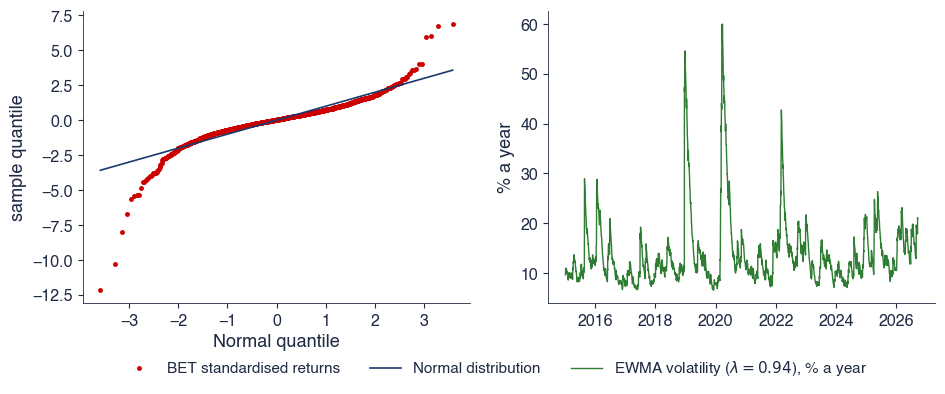

{'perf': {'mean_log': 13.226992699910795,
  'vol': 15.540961380798963,
  'sharpe': 0.9287025200653658,
  'sharpe_se': 0.3497314762136679,
  'mdd': -31.124049022725607},
 'moments': {'skew': -1.414259123301573,
  'exkurt': 17.846977610123204,
  'jb': 39794.03089442697,
  'p_jb': 0.0},
 'hill': {'k': 73,
  'alpha': 2.1936757567587932,
  'se': np.float64(0.25675032714738905)},
 'LB r': 54.65758938538834,
 'LB r^2': 700.5821798155231,
 'garch': {'mu': 0.08693258233103839,
  'omega': 0.06907106646893141,
  'alpha': 0.18460483374262668,
  'beta': 0.7400591629270556,
  'nu': 5.0101104248067,
  'pers': 0.9246639966696824,
  'half_life': 8.849645322988254},
 'VaR 1% HS': 2.722658259456523,
 'VaR 1% Normal': 2.233543234957316,
 'ES 2.5% HS': 3.210295649484295,
 'ES 2.5% Normal': 2.244801676336145}

In [14]:
# Solution
b1 = b1_checkup('bet', save=False)
{'perf': {c: b1['perf'][c] for c in ['mean_log', 'vol', 'sharpe', 'sharpe_se', 'mdd']}, 'moments': b1['mom'],
 'hill': b1['hill'], 'LB r': b1['lb_r']['q'], 'LB r^2': b1['lb_r2']['q'], 'garch': b1['garch'],
 'VaR 1% HS': b1['var_hs'], 'VaR 1% Normal': b1['var_n'], 'ES 2.5% HS': b1['es_hs'], 'ES 2.5% Normal': b1['es_n']}

**Interpretation of the result.** (1) Heavy tails: the Normal VaR 1% is far too low. (2) Returns are weakly autocorrelated, squared returns strongly: volatility clustering. (3) The Sharpe ratio is less than three standard errors from zero.

## B2 [Proposed]: backtesting VaR 1% for the S&P 500 and Bitcoin

**Question.** Does a heavy-tailed method beat a Normal method with fast volatility? Model: B1 and Seminar 10, B3.

1. Compute the one-day VaR 1% by historical simulation on the last 500 returns.
2. Compute the one-day EWMA-Normal VaR 1% with $\lambda = 0.94$.
3. Count the exceptions of each method and run the Kupiec test.
4. Find the largest number of exceptions in any 250 consecutive days.
5. Interpretation: which method would a supervisor accept for each series?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Proposed]: efficiency and memory in two windows

**Question.** Did the BET and the S&P 500 become more efficient after 2015? Model: A3; Seminar 7, B1 and Seminar 11, B1.

1. Compute VR(5) and the robust $Z^*(5)$ in each window (2000–2014 and 2015–2026).
2. Compute the Hurst exponent (R/S) of $r_t$ and of $|r_t|$ in each window.
3. Interpretation: did the BET become more efficient after 2015?

**Report:** one table of sixteen numbers and two sentences.

In [ ]:
# Your code here


# Part C: AI critique

## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant summarised the course for the exam, with the course data. It answered:

- (a) the VaR 99% of the BET since 2015 is a negative number, the 1% quantile;
- (b) the BET returns are close to Normal, because the skewness is small;
- (c) Bitcoin's annual volatility is its daily standard deviation times $\sqrt{252}$;
- (d) for the S&P 500 a volatility shock halves in $1/(1 - \alpha - \beta)$ days;
- (e) the Hurst exponent of $|r_t|$ is above 0.8 for the S&P 500, so its returns are predictable;
- (f) for Normal returns, ES 2.5% and VaR 1% are almost the same number.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
